# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from skimage import measure

from TherMIFASOL.src.GlobalVariables import (
    T_SOLIDUS, T_LIQUIDUS, FAC, COLUMNS_CRED, LINES_CRED
)
from TherMIFASOL.src.BoardCardFilterVariable import (
    boundaries_data_selection, boundaries_data_color, colors_plots_cordon, \
    params_clip
)
from TherMIFASOL.src.data.PYROMETER_functions import (
    collect_data_pyrometer, show_acquisition_time, show_acquisition_start
)
from TherMIFASOL.src.data.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.src.models.EmissivityEmpiricalLaws import (
    wagner_inspired_emissivity, mean_absolute_image_difference
)
from TherMIFASOL.src.tools.visualization import (
    interpolate_color, interpolate_to_black, plot_differences
)

In [2]:
data_path_CRED = "../../../data/experiences/BoardCardFilter/DEC1/CRED/data"
data_path_pyrometer = "../../../data/experiences/BoardCardFilter/DEC1/pyrometer/"

tables_path = "../../../tables/"
array_nuc = np.load(os.path.join(tables_path, "NUC/NUC_2pts_Temp500__diaphMIN_bois2.npy"))
array_calibration = np.load(os.path.join(tables_path, "FLUX/FLUX_IT100_deg1_diaphMIN_bois2_TRUSTWORTHY.npy"))

saving_path = "../../../results/BoardCardFilter/"

# Wagner like phenomenological law

## Pyrometer section

In [3]:
list_beads:list = [11, 12, 13, 14, 15, 16]
FULL_INFO = {id_:{} for id_ in list_beads}
LOCAL_INFO = {id_:{} for id_ in list_beads}

### Subselection

In [4]:
for id_bead in list_beads:
    path_data_bead:str = os.path.join(data_path_pyrometer, f"WLAM_H322_14150_{id_bead}.csv")
    dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)

    FULL_INFO[id_bead] = dict_data_bead

    low_boundary, _ = boundaries_data_selection[id_bead]
    mask = dict_data_bead['array time'] > low_boundary

    LOCAL_INFO[id_bead]['array time'] = dict_data_bead['array time'][mask] - low_boundary
    LOCAL_INFO[id_bead]['array MAtemp2C'] = dict_data_bead['array MAtemp2C'][mask]
    LOCAL_INFO[id_bead]['array MAemissivity'] = dict_data_bead['array MAemissivity'][mask]


### Temporal pyrometric readings

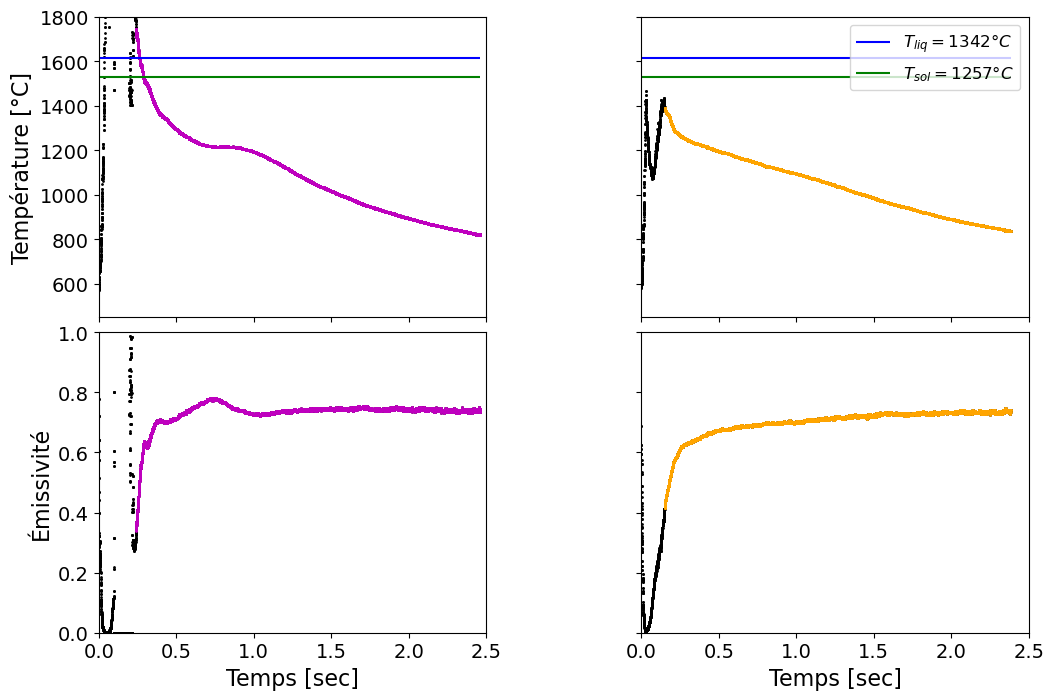

In [5]:
cordon_selection = [11, 13]

fig, axs = plt.subplots(2, len(cordon_selection), figsize=(12, 8), sharex='col', sharey='row', gridspec_kw={'wspace': 0.4, 'hspace': 0.05})  # 2 lignes, 3 colonnes, partage x/y
for idx, cordon in enumerate(cordon_selection):
    low_boundary, high_boundary = boundaries_data_selection[cordon]
    TIME = LOCAL_INFO[cordon]['array time']
    TEMP2C = LOCAL_INFO[cordon]['array MAtemp2C']
    EPSILON = LOCAL_INFO[cordon]['array MAemissivity']
    MASK_COLOR = TIME > boundaries_data_color[cordon]

    # Tracer la température (ligne 1)
    axs[0, idx].scatter(TIME, TEMP2C, s=1, c='k')
    axs[0, idx].scatter(TIME[MASK_COLOR], TEMP2C[MASK_COLOR], s=1, color=colors_plots_cordon[cordon])
    axs[0, idx].hlines(y=T_LIQUIDUS, xmin=TIME[0], xmax=TIME[-1], colors='b', label=r'$T_{liq} = 1342 °C$')
    axs[0, idx].hlines(y=T_SOLIDUS, xmin=TIME[0], xmax=TIME[-1], colors='g', label=r'$T_{sol} = 1257 °C$')

    # axs[1, idx].hlines(y=0.73, xmin=TIME[0], xmax=TIME[-1], color='r', ls='--', label=r'$\varepsilon$ = 0.73')
    axs[0, idx].set_ylim(ymin=450, ymax=1800)
            
    if idx == 1:
        axs[0, idx].legend(fontsize=12)
        # axs[1, idx].legend(fontsize=12, loc='lower right')
    
    if idx == 0:
        axs[0, idx].set_ylabel('Température [°C]', fontsize=16)
        axs[1, idx].set_ylabel('Émissivité', fontsize=16)

    # Tracer l'émissivité (ligne 2)
    axs[1, idx].scatter(TIME, EPSILON, c='k', s=1)
    axs[1, idx].scatter(TIME[MASK_COLOR], EPSILON[MASK_COLOR], color=colors_plots_cordon[cordon], s=1)
    axs[1, idx].set_ylim(0, 1)      
    
    axs[1, idx].set_xlabel('Temps [sec]', fontsize=16)

for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlim(0, 2.5)

# fig.tight_layout()
# plt.savefig("../resultats/data_selected_c11_c13.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

## Temperature - Emissivity plan 

### Plot of selected data

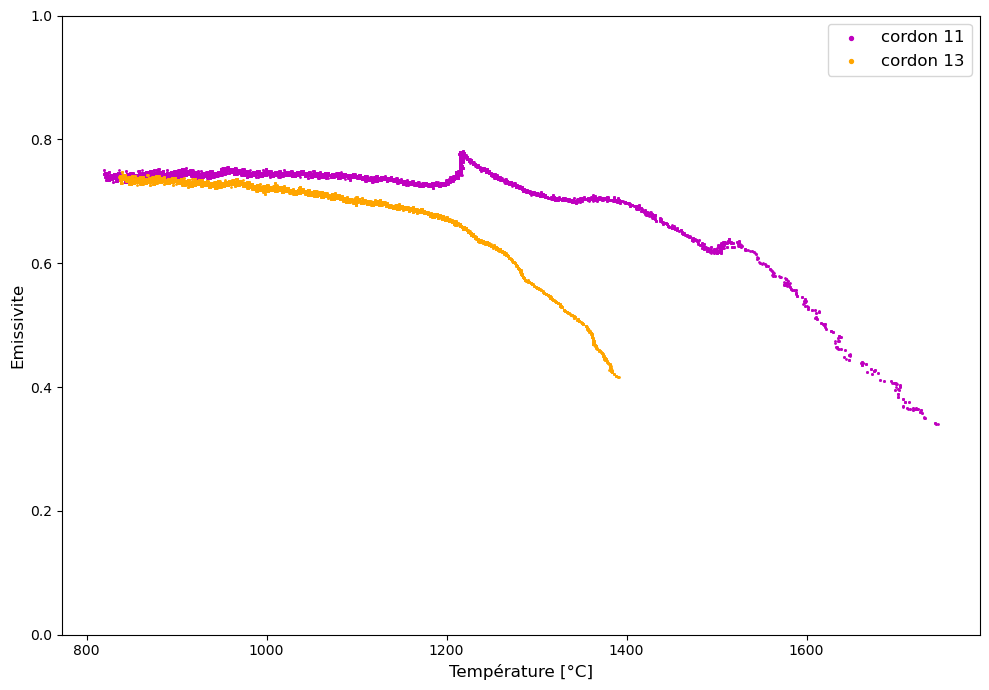

In [6]:
cordon_selection = [11, 12, 13, 14, 15, 16]
cordon_selection = [11, 13]

temp_fake = np.arange(500, 1700)
fig, ax1 = plt.subplots(1, 1, figsize=(10,7))
for idx, cordon in enumerate(cordon_selection):
    low_boundary, high_boundary = boundaries_data_selection[cordon]
    TIME = LOCAL_INFO[cordon]['array time']
    TEMP2C = LOCAL_INFO[cordon]['array MAtemp2C']
    EPSILON = LOCAL_INFO[cordon]['array MAemissivity']
    MASK_COLOR = TIME > boundaries_data_color[cordon]

    ax1.scatter([np.mean(TEMP2C)], [-5], c=colors_plots_cordon[cordon], s=8, label=f'cordon {cordon}')
    ax1.scatter(TEMP2C[MASK_COLOR], EPSILON[MASK_COLOR], s=1, c=colors_plots_cordon[cordon])

ax1.set_ylabel('Emissivite', fontsize=12)
ax1.set_ylim(0,1)
ax1.set_xlabel('Température [°C]', fontsize=12)
ax1.legend(fontsize=12)

ax1.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
plt.show()

### Selected data & analytical fitted laws

#### Color map creation

In [7]:
iterations = [0, 0.8, 1.6]  # Profondeur en mm, avec 1.6 mm ajouté ici
iterations2 = [1.6, 2.6, 3.2]  # Profondeur en mm

# Inverser l'ordre pour que 0 soit en haut de la colorbar
iterations = sorted(iterations, reverse=True)
iterations2 = sorted(iterations2, reverse=True)

# Création d'un dégradé fluide de magenta à orange et d'orange à noir
scalars_magenta_to_orange = np.linspace(0, 1, 90)  # De magenta à orange
colors_magenta_to_orange = [interpolate_color((0.75, 0, 0.75), (1, .647, 0), scalar) for scalar in scalars_magenta_to_orange]

# Création d'un dégradé fluide d'orange à noir
scalars_orange_to_black = np.linspace(0, 1, 90)  # De orange à noir
colors_orange_to_black = interpolate_to_black((1, .647, 0), scalars_orange_to_black)
# colors_orange_to_green = [interpolate_color((1, .647, 0), (0, 0.5, 0), scalar) for scalar in scalars_orange_to_black]

# Combinaison des deux pour un dégradé fluide de magenta -> orange -> noir
colors_combined = colors_magenta_to_orange + colors_orange_to_black

# Création de la colormap avec la combinaison des couleurs
cm_smooth = LinearSegmentedColormap.from_list("magenta_to_black", colors_combined, N=200)
norm = Normalize(vmin=min(iterations), vmax=max(iterations2))  # Ajustement pour inclure la profondeur totale

#### Subdata collection

In [8]:
MASK15 = LOCAL_INFO[15]['array time'] > boundaries_data_color[15]
temperature15 = LOCAL_INFO[15]['array MAtemp2C'][MASK15]
epsilon15 = LOCAL_INFO[15]['array MAemissivity'][MASK15]

MASK13 = LOCAL_INFO[13]['array time'] > boundaries_data_color[13]
temperature13 = LOCAL_INFO[13]['array MAtemp2C'][MASK13]
epsilon13 = LOCAL_INFO[13]['array MAemissivity'][MASK13]

MASK11 = LOCAL_INFO[11]['array time'] > boundaries_data_color[11]
temperature11 = LOCAL_INFO[11]['array MAtemp2C'][MASK11]
epsilon11 = LOCAL_INFO[11]['array MAemissivity'][MASK11]

#### Plot data

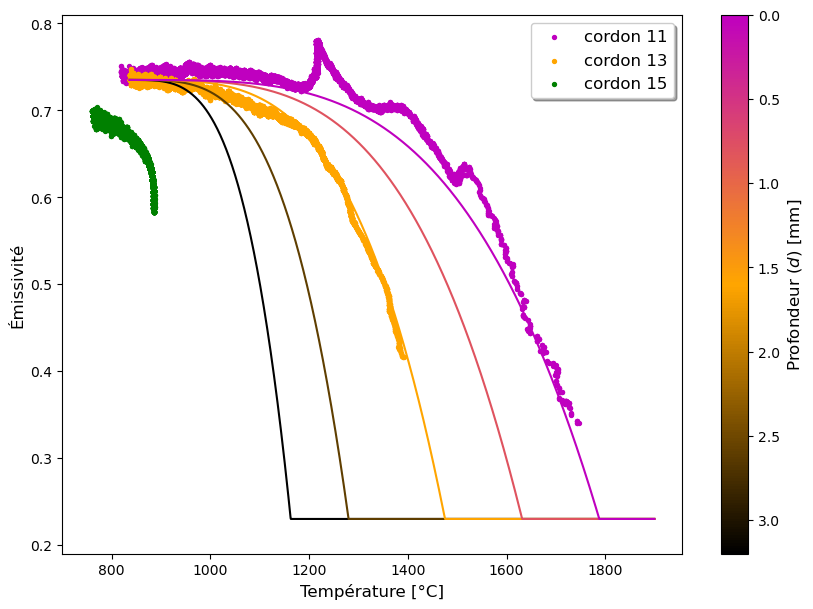

In [9]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))
temp_fake = np.arange(700, 1900, 0.5)

# Ajout des scatter plots pour les cordons 11 et 13
ax1.scatter(temperature11, epsilon11, label='cordon 11', color='m', s=8)
ax1.scatter(temperature13, epsilon13, label='cordon 13', color='orange', s=8)
ax1.scatter(temperature15, epsilon15, label='cordon 15', color='g', s=8)

# Itérations pour les lignes avec la nouvelle loi
for cpt, d in enumerate(iterations2 + iterations[1:]):
    new_eps = wagner_inspired_emissivity(
        temperature=temp_fake,
        depth=d, 
        unit="mm", 
        block=False, 
        evolution="linear", 
        eps_min=0.23
    )

    ax1.plot(temp_fake, new_eps, c=cm_smooth(norm(d)))

# Ajustement de la colorbar avec inversion des valeurs (profondeur de 0 en haut)
sm = plt.cm.ScalarMappable(cmap=cm_smooth, norm=norm)
sm.set_array([])  # Nécessaire pour utiliser la colorbar
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label(r'Profondeur ($d$) [mm]', fontsize=12)
cbar.ax.tick_params(axis='y', which='major', labelsize=10)
cbar.ax.invert_yaxis()  # Inverse l'axe de la colorbar pour montrer 0 en haut

# Ajustements finaux
ax1.set_ylim(0.19, 0.81)
ax1.set_xlim(xmin=700)
ax1.tick_params(axis='both', which='major', labelsize=10)
plt.legend(['cordon 11', 'cordon 13', 'cordon 15'], loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.xlabel('Température [°C]', fontsize=12)
plt.ylabel("Émissivité", fontsize=12)
# plt.savefig("../resultats/analytical_law.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

## Camera section

### Depth filter array
The phenomenological law is function of the depth from the top surface. The following array allow this consideration while array computation. 

#### Random data for testing

In [10]:
c_cordon = 13
img = 320
path_raw_data_layer = os.path.join(data_path_CRED, f"layer_{c_cordon}")

# Raw image
try:
    dl_raw = load_cred_array(os.path.join(path_raw_data_layer, f"im_{img}.npy"))
except Exception as e:
    print(f"Error processing images: {e}")
    raise

# Thermal image from homogenous emissivity field
thermal_image_uniform_emissivity_field = np.flipud(
        dl_to_thermo(
            dl_raw=dl_raw,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=0.73
        )
)


##### Raw image

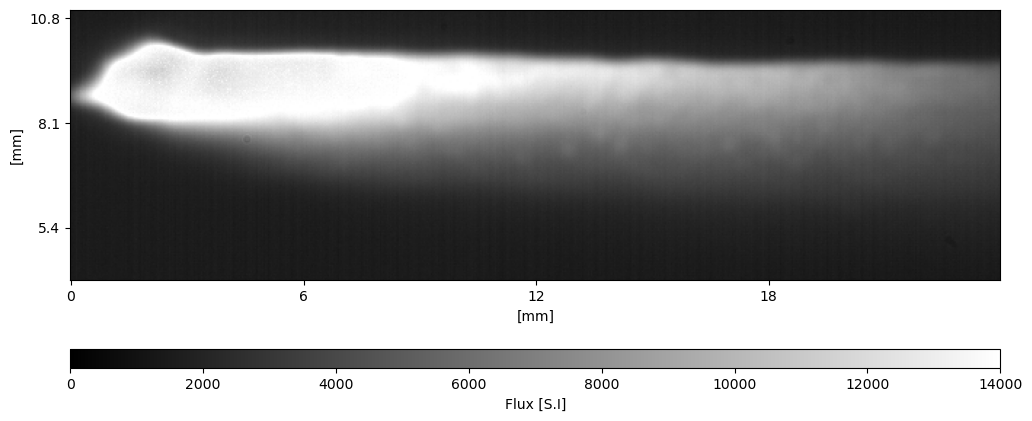

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

# Affichage de l'image
IMAGE = np.flipud(dl_raw)
image = ax.imshow(IMAGE, vmin=0, vmax=14000, cmap='grey')
ax.set_xlabel('[mm]')
ax.set_ylabel('[mm]')

# Définition des ticks factices
ax.set_xticks(np.arange(0, COLUMNS_CRED, 160))
ax.set_yticks(np.arange(LINES_CRED, 0, -72))
ax.set_xticklabels([f"{x:.0f}" for x in np.arange(0, COLUMNS_CRED, 160)*FAC])
ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, LINES_CRED, 72)*FAC])

lim = 218
ax.set_ylim(lim+186, lim)
cbar = fig.colorbar(image, orientation='horizontal', shrink=1, aspect=50, pad=0.15)
cbar.set_label('Flux [S.I]')

# plt.savefig("../resultats/image_ref_PX.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

##### Depth mask

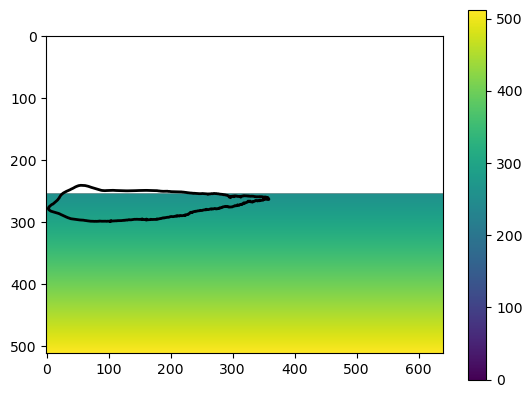

In [12]:
_, depth_matrix = np.meshgrid(
    np.arange(0, 640, 1),
    np.arange(0, 512, 1),
)

contours = measure.find_contours(
    thermal_image_uniform_emissivity_field, 
    T_SOLIDUS
)
x_pos, y_pos = max(contours, key=len).T

upper_limit=255  # top surface : equivalent to 0 mm
mask_prof = np.zeros_like(depth_matrix, dtype=bool)
mask_prof[:upper_limit,:]=True  # True == unwanted values
plt.plot(y_pos, x_pos, color='black', linewidth=2)
plt.imshow(np.ma.masked_array(depth_matrix, mask_prof), vmin=0, vmax=512)
plt.colorbar()
plt.show()

## Fixed point algorithm

### Algorithm's parameters

In [13]:
No_iteration = 20
emissivity_starts={
    0:{
        'emissivity':0.4,
        'color':'r'
        },
    1:{
        'emissivity':0.5,
        'color':'g'
        },
    2:{
        'emissivity':0.73,
        'color':'b'
        },
    3:{
        'emissivity':0.85,
        'color':'k'
        }
}

### Algorithm

In [14]:
global_results={}

# Choice for evolution law among phenomenological law :
# # quadratic / linear
evolution = 'linear'
block = False


# parameter for fixed point algorithm
c_cam = 13 # cordon : c_cam
path_raw_data_layer = os.path.join(data_path_CRED, f"layer_{c_cam}")
img = 320 # image : img

for key in emissivity_starts.keys():

    # Initializing dictionary for local results
    local_results={}

    # Set the local values
    emissivity=emissivity_starts[key]['emissivity']
    local_results['eps']=emissivity
    local_results['color']=emissivity_starts[key]['color']

    # Empty array for fixe point method
    thermal_images = np.zeros((No_iteration+1, LINES_CRED, COLUMNS_CRED))
    emissivity_maps = np.ones((No_iteration+1, LINES_CRED, COLUMNS_CRED))*emissivity

    # Load raw image for work
    dl_raw = load_cred_array(os.path.join(path_raw_data_layer, f"im_{img}.npy"))
    thermal_images[0]=dl_to_thermo(
        dl_raw=dl_raw,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=emissivity
    ) - 273.15  # Celsius degree thermal maps
    
    for iteration in range(1, No_iteration+1):

        # Update thermal maps
        current_thermo = np.copy(thermal_images[iteration-1])

        # Emissivity map from phenomenological law
        emissivity_maps[iteration]=wagner_inspired_emissivity(
            temperature=current_thermo, 
            depth=np.flipud(depth_matrix), 
            unit='px',
            block=block,
            evolution=evolution,
            eps_min=0.23
        )

        # New thermal image from the phenomenological emissivity field
        thermal_images[iteration] = dl_to_thermo(
            dl_raw=dl_raw,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=emissivity_maps[iteration]
        ) - 273.15  # Celsius degree thermal maps

    # Flip up-side down every images (Camera was up-side down during the recording)
    thermal_all = np.asarray([np.flipud(thermal_images[i]) for i in range(No_iteration+1)])
    emissivity_all = np.asarray([np.flipud(emissivity_maps[i]) for i in range(No_iteration+1)])

    local_results['thermal images']=thermal_all
    local_results['emissivity maps']=emissivity_all

    global_results[key]=local_results


### Visualization

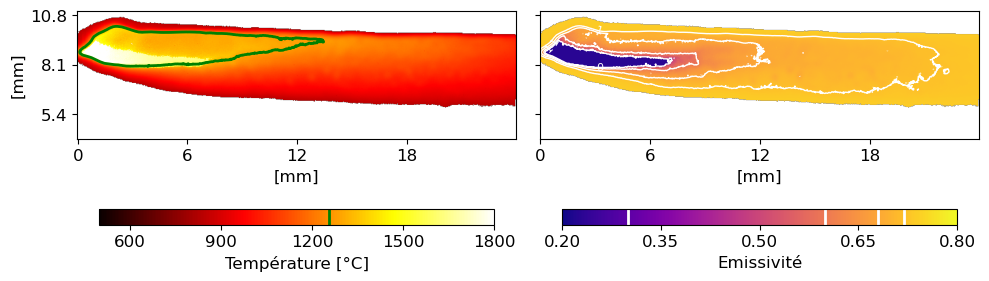

In [15]:
# Limits and levels
lim_low = 0.2
lim_high = 0.8
custom_levels = [0.3, 0.6, 0.68, 0.72]
T_low = 500
T_high = 1800
ticks_emi = np.linspace(lim_low, lim_high, 5)
ticks_temp = np.linspace(600, T_high, 5)
lim = 218

mask = np.ones_like(global_results[key]['thermal images'][0])
mask[200:360,:]= False
X, Y = np.meshgrid(np.arange(COLUMNS_CRED), np.arange(LINES_CRED))

# Select thermal and emissivity maps from the study case
key = 1
iteration = 20
image1 = np.ma.masked_array(global_results[key]['thermal images'][iteration], mask)   
image2 = np.ma.masked_array(global_results[key]['emissivity maps'][iteration], mask)

contours_1 = measure.find_contours(image1, T_SOLIDUS-273.15)
x_pos_solidus, y_pos_solidus = max(contours, key=len).T


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Images
im1 = axes[0].imshow(image1, vmin=T_low, vmax=T_high, cmap='hot')
axes[0].plot(y_pos_solidus, x_pos_solidus , color='green', linewidth=2)
iso_emi = axes[1].contour(X, Y, image2, levels=custom_levels, colors='white', linewidths=1)
ax.clabel(iso_emi, inline=False, fontsize=8, fmt='%.0f')
im2 = axes[1].imshow(image2, vmin=lim_low, vmax=lim_high, cmap='plasma')

# Colorbar
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='horizontal', shrink=0.9, aspect=25, pad=0.15)
cbar1.set_label('Température [°C]', fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1], orientation='horizontal', shrink=0.9, aspect=25, pad=0.15)
cbar2.set_label('Emissivité', fontsize=12)


# Colorbar ticks values/ names/ font size
cbar1.set_ticks(ticks_temp)
cbar1.set_ticklabels([f"{t:.0f}" for t in ticks_temp])
cbar1.ax.tick_params(labelsize=12)
cbar2.set_ticks(ticks_emi)
cbar2.set_ticklabels([f"{t:.2f}" for t in ticks_emi])
cbar2.ax.tick_params(labelsize=12)

# Labels
axes[0].set_xlabel('[mm]', fontsize=12)
axes[0].set_ylabel('[mm]', fontsize=12)
axes[1].set_xlabel('[mm]', fontsize=12)

# Mark on colorbar 
cbar1.ax.axvline(T_SOLIDUS-273.15, color='green', linewidth=2)
for level in custom_levels:
    cbar2.ax.axvline(level, color='white', linewidth=2, linestyle='-')

# Ticks values/ names/ font size
for ax in axes.flatten():
    ax.set_xticks(np.arange(0, COLUMNS_CRED, 160))
    ax.set_yticks(np.arange(LINES_CRED, 0, -72))
    ax.set_xticklabels([f"{x:.0f}" for x in np.arange(0, COLUMNS_CRED, 160)*FAC], fontsize=12)
    ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, LINES_CRED, 72)*FAC], fontsize=12)
    ax.set_ylim(lim+186, lim)

plt.tight_layout()
# plt.savefig("../resultats/Temp_and_emi_fields_Wagner.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

#### Tools for visualization
Initialization of point of interests & relative position according to the melt pool

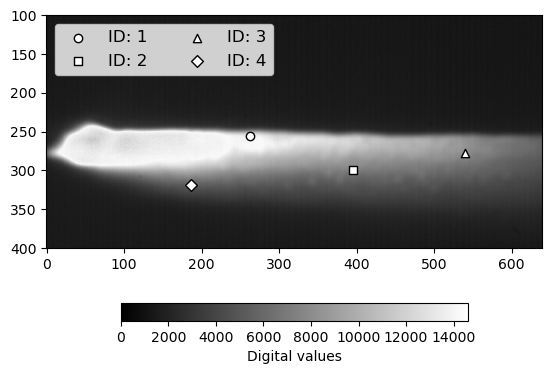

In [16]:
POI= {
    1:{
        'XY':(256, 262),
        'marker':"o"
        }, 
    2:{
        'XY':(300, 395),
        'marker':'s'
        },
    3:{
        'XY':(277, 540),
        'marker':'^'
        },
    4:{
        'XY':(319, 186),
        'marker':'D'
        }
}

dl_raw = load_cred_array(os.path.join(path_raw_data_layer, f"im_{img}.npy"))

fig, ax = plt.subplots()

im = ax.imshow(np.flipud(dl_raw), 'gray')

for ID in range(1,5):
    xpos, ypos = POI[ID]['XY']
    ax.scatter(ypos, xpos, marker=POI[ID]['marker'], edgecolors='k', facecolor='w', label=f'ID: {ID}')
plt.legend(ncols=2, loc='upper left', fontsize=12)
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.7)
cbar.set_label('Digital values')
ax.set_ylim(400, 100)
plt.show()


0
1
2
3


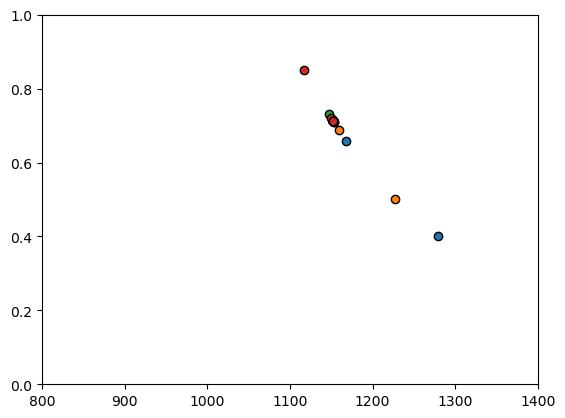

In [17]:
# chose id for position
ID = 3
emissivity_start_ID = 1

x_target, y_target = POI[ID]['XY']
for emissivity_start_ID in emissivity_starts.keys():
    print(emissivity_start_ID)
    temperature_evolution = global_results[emissivity_start_ID]['thermal images'][:,x_target, y_target]
    emissivity_evolution = global_results[emissivity_start_ID]['emissivity maps'][:,x_target, y_target]

    plt.scatter(
        temperature_evolution,
        emissivity_evolution,

        edgecolor='k'
    )
plt.ylim(0,1)
plt.xlim(800,1400)
plt.show()

## Convergence

In [18]:
# Constants
REFERENCE_KEY = 2
REFERENCE_INDEX = 20
CUTOFF_ROW = 360

# Extract reference images and set NaN values
thermal_reference_image = global_results[REFERENCE_KEY]['thermal images'][REFERENCE_INDEX]
thermal_reference_image[CUTOFF_ROW:,:]=np.nan
emissivity_reference_image=global_results[REFERENCE_KEY]['emissivity maps'][REFERENCE_INDEX]
emissivity_reference_image[CUTOFF_ROW:,:]=np.nan

# Print reference emissivity value
print(f"Reference Emissivity: {global_results[REFERENCE_KEY]['eps']}")

# Initialize arrays to store differences
temperature_differences = np.full((No_iteration + 1, len(global_results)), fill_value=np.nan)
emissivity_differences = np.full((No_iteration + 1, len(global_results)), fill_value=np.nan)

# Iterate over each key in global_results
for emissivity_id in global_results.keys():
    thermal_images = global_results[emissivity_id]['thermal images']
    emissivity_maps = global_results[emissivity_id]['emissivity maps']

    # Iterate over each iteration index
    for iteration in range(No_iteration + 1):
        # Copy and modify images for comparison
        current_thermal_image = np.copy(thermal_images[iteration])
        current_thermal_image[CUTOFF_ROW:, :] = np.nan

        current_emissivity_image = np.copy(emissivity_maps[iteration])
        current_emissivity_image[CUTOFF_ROW:, :] = np.nan

        # Calculate and store differences
        temperature_differences[iteration, emissivity_id] = mean_absolute_image_difference(
            current_thermal_image, thermal_reference_image
        )
        emissivity_differences[iteration, emissivity_id] = mean_absolute_image_difference(
            current_emissivity_image, emissivity_reference_image
        )

Reference Emissivity: 0.73


/tmp/ipykernel_37329/189844423.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


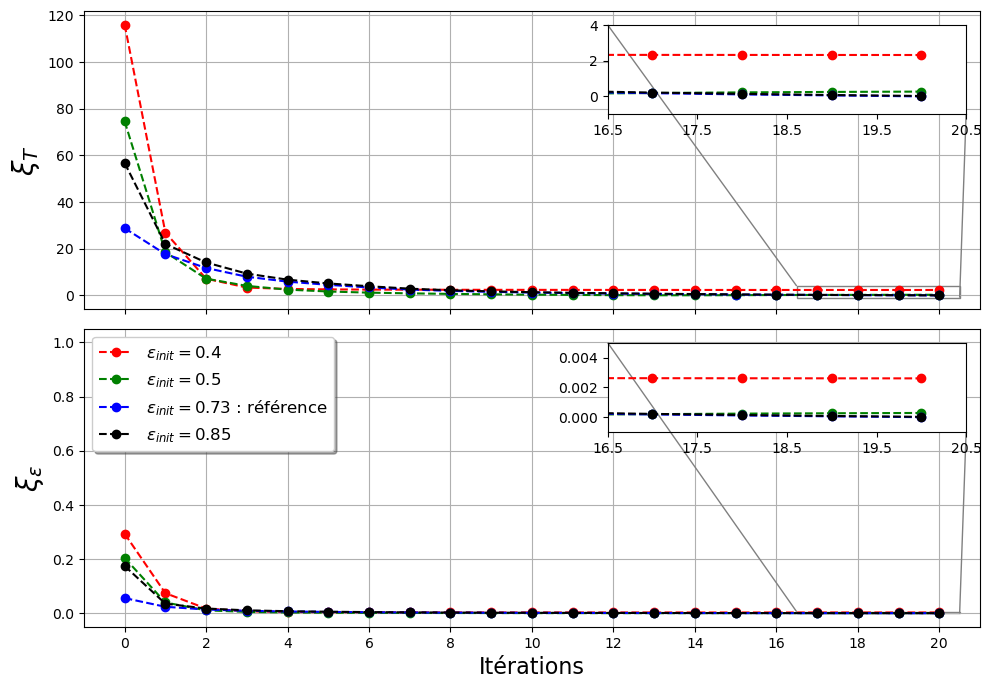

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

x_values = np.arange(No_iteration + 1)

# Plot temperature differences
plot_differences(
    ax=ax1,
    data=temperature_differences,
    global_results=global_results,
    reference_id=REFERENCE_KEY,
    x_values=x_values,
    ylabel=r'$\xi_T$',
    zoom_params={'xlim': (16.5, 20.5), 'ylim': (-1, 4)}
)

# Plot emissivity differences
plot_differences(
    ax=ax2,
    data=emissivity_differences,
    global_results=global_results,
    reference_id=REFERENCE_KEY,
    x_values=x_values,
    ylabel=r'$\xi_{\varepsilon}$',
    zoom_params={'xlim': (16.5, 20.5), 'ylim': (-0.001, 0.005)}
)

ax2.set_xlabel("Itérations", fontsize=16)
ax2.legend(fontsize=12, frameon=True, shadow=True, loc='upper left')
ax2.set_ylim(-0.05, 1.05)
ax1.set_xticks(np.arange(0, 21, 2))
ax2.set_xticks(np.arange(0, 21, 2))

fig.tight_layout()
# plt.savefig("../resultats/convergence_PX.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### Erreur relative

29.6497507038894


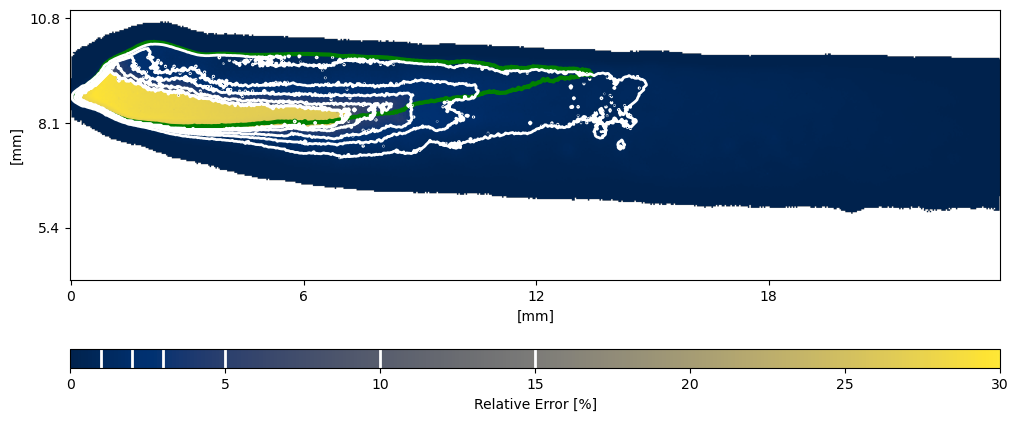

In [23]:
key=2
iteration=20

# Thermal image from heterogenous emissivity field
heterogenous_field = np.ma.masked_array(global_results[key]['thermal images'][iteration], mask)

# Thermal image from homogenous emissivity field
uniform_field = np.flipud(
        dl_to_thermo(
            dl_raw=dl_raw,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=0.73
        ) - 273.15
)

absolute_error = np.abs(uniform_field - heterogenous_field)
relative_error = 100 * absolute_error / uniform_field


print(np.nanmax(relative_error))

fig, ax = plt.subplots(figsize=(12, 6))

# Find contours
contours = measure.find_contours(uniform_field, T_SOLIDUS-273.15)
x_pos_contour, y_pos_contour = max(contours, key=len).T

# Create meshgrid
X, Y = np.meshgrid(np.arange(COLUMNS_CRED), np.arange(LINES_CRED))

# Plot contours and relative error image
custom_levels = [1, 2, 3, 5, 10, 15]
ax.plot(y_pos_contour, x_pos_contour, color='green', linewidth=3)
iso_contour = ax.contour(X, Y, relative_error, levels=custom_levels, colors='white', linewidths=2)
image = ax.imshow(np.ma.masked_array(relative_error, mask), vmin=0, vmax=30, cmap='cividis')

# Set labels and ticks
ax.set_xlabel('[mm]')
ax.set_ylabel('[mm]')
ax.set_xticks(np.arange(0, COLUMNS_CRED, 160))
ax.set_yticks(np.arange(LINES_CRED, 0, -72))
ax.set_xticklabels([f"{x:.0f}" for x in np.arange(0, COLUMNS_CRED, 160) * FAC])
ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, LINES_CRED, 72) * FAC])
ax.set_ylim(lim + 186, lim)

# Add colorbar
cbar = fig.colorbar(image, orientation='horizontal', shrink=1, aspect=50, pad=0.15)
cbar.set_label('Relative Error [%]')
for level in custom_levels:
    cbar.ax.axvline(level, color='white', linewidth=2, linestyle='-')

# plt.savefig("../resultats/erreur_relative_Wagner.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()